# **AI 600 Deep Learning Assignment 2**

## Getting Started

In [4]:
# from google.colab import drive
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F

In [5]:
VAL_SIZE = 256
TRAIN_SIZE = 256
TEST_SIZE = 256
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
EPOCHS = 40
PANCAKE_LAYERS = [1024, 1024]
TOWER_LAYERS = [256, 256, 256, 256, 256, 256]
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params


Using device: cpu


In [3]:
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [6]:
# with np.load('/content/drive/MyDrive/AI600Assignment2/quickdraw_train.npz') as data:
with np.load('quickdraw_train.npz') as data:  
  X = data['x_train'].astype(np.float32)
  Y = data['y_train']
  class_names = data['class_names']
# with np.load('/content/drive/MyDrive/AI600Assignment2/quickdraw_test.npz') as data:
with np.load('quickdraw_test.npz') as data:
  X_test = data['test_images']

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape, X_test.shape   

((60000, 784), (15000, 784))

In [8]:
X_train, X_val, Y_train, Y_val = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

X_train_tensor = torch.from_numpy(X_train)
Y_train_tensor = torch.from_numpy(Y_train).long()
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=TRAIN_SIZE, shuffle=True)

X_val_tensor = torch.from_numpy(X_val)
Y_val_tensor = torch.from_numpy(Y_val).long()
val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
val_loader = DataLoader(dataset=val_dataset, batch_size=VAL_SIZE, shuffle=False)

X_test_float = X_test.astype(np.float32)
X_test_scaled = scaler.transform(X_test_float)
X_test_tensor = torch.from_numpy(X_test_scaled)
test_dataset = TensorDataset(X_test_tensor)
test_loader = DataLoader(dataset=test_dataset, batch_size=TEST_SIZE, shuffle=False)


## Pancake and Tower

In [21]:
class Pancake(nn.Module):
  def __init__(self, input_size=784, num_classes=15, hidden_layers=PANCAKE_LAYERS):
    super(Pancake, self).__init__()
    layers = [nn.Flatten()]
    current_dim = input_size
    for h_dim in hidden_layers:
        layers.append(nn.Linear(current_dim, h_dim))
        layers.append(nn.ReLU())
        current_dim = h_dim
    layers.append(nn.Linear(current_dim, num_classes))
    self.network = nn.Sequential(*layers)

  def forward(self, x):
    return self.network(x)


In [22]:
model = Pancake().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [23]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_pancake.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.0441 | Train Acc: 65.79%
Val Loss:   0.8456 | Val Acc:   72.16%
------------------------------
Epoch 2/40
Train Loss: 0.7348 | Train Acc: 75.91%
Val Loss:   0.7984 | Val Acc:   74.09%
------------------------------
Epoch 3/40
Train Loss: 0.5802 | Train Acc: 80.86%
Val Loss:   0.7846 | Val Acc:   75.01%
------------------------------
Epoch 4/40
Train Loss: 0.4675 | Train Acc: 84.34%
Val Loss:   0.7837 | Val Acc:   76.12%
------------------------------
Epoch 5/40
Train Loss: 0.3526 | Train Acc: 88.00%
Val Loss:   0.8340 | Val Acc:   75.87%
------------------------------
Epoch 6/40
Train Loss: 0.2665 | Train Acc: 90.92%
Val Loss:   0.9029 | Val Acc:   76.96%
------------------------------
Epoch 7/40
Train Loss: 0.1893 | Train Acc: 93.61%
Val Loss:   0.9935 | Val Acc:   75.75%
------------------------------
Epoch 8/40
Train Loss: 0.1441 | Train Acc: 95.05%
Val Loss:   1.1415 | Val Acc:   75.88%
------------------------------
Epoch 9/40
Train Loss: 0.1053 | Train Ac

In [24]:
count_parameters(model)

1868815

In [25]:
class Tower(nn.Module):
  def __init__(self, input_size=784, num_classes=15, hidden_layers=TOWER_LAYERS):
    super(Tower, self).__init__()
    layers = [nn.Flatten()]
    current_dim = input_size
    for h_dim in hidden_layers:
        layers.append(nn.Linear(current_dim, h_dim))
        layers.append(nn.ReLU())
        current_dim = h_dim
    layers.append(nn.Linear(current_dim, num_classes))
    self.network = nn.Sequential(*layers)


  def forward(self, x):
      return self.network(x)


In [26]:
model = Tower().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [27]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_tower.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.3332 | Train Acc: 53.92%
Val Loss:   1.0255 | Val Acc:   64.78%
------------------------------
Epoch 2/40
Train Loss: 0.9212 | Train Acc: 68.51%
Val Loss:   0.9122 | Val Acc:   69.11%
------------------------------
Epoch 3/40
Train Loss: 0.8053 | Train Acc: 72.63%
Val Loss:   0.8530 | Val Acc:   71.77%
------------------------------
Epoch 4/40
Train Loss: 0.7096 | Train Acc: 76.18%
Val Loss:   0.8000 | Val Acc:   73.79%
------------------------------
Epoch 5/40
Train Loss: 0.6302 | Train Acc: 78.82%
Val Loss:   0.8283 | Val Acc:   73.88%
------------------------------
Epoch 6/40
Train Loss: 0.5690 | Train Acc: 80.74%
Val Loss:   0.8018 | Val Acc:   74.97%
------------------------------
Epoch 7/40
Train Loss: 0.5086 | Train Acc: 82.95%
Val Loss:   0.7946 | Val Acc:   74.90%
------------------------------
Epoch 8/40
Train Loss: 0.4624 | Train Acc: 84.49%
Val Loss:   0.8883 | Val Acc:   74.47%
------------------------------
Epoch 9/40
Train Loss: 0.4113 | Train Ac

In [32]:
count_parameters(model)

533775

## Champion Try Runs (Skip Section - not for marking)

In [9]:
CHAMPION_LAYERS = [1024, 512, 512, 512]

In [10]:
class Champion(nn.Module):
  def __init__(self, input_size=784, num_classes=15, hidden_layers=CHAMPION_LAYERS):
    super(Champion, self).__init__()
    layers = [nn.Flatten()]
    current_dim = input_size
    for h_dim in hidden_layers:
        layers.append(nn.Linear(current_dim, h_dim))
        # layers.append(nn.BatchNorm1d(h_dim)) # Iteration 3 addition
        layers.append(nn.LayerNorm(h_dim)) # Final experimentation
        # layers.append(nn.ReLU()) # Iteration 4 removal
        layers.append(nn.GELU()) # Iteration 4 addition
        layers.append(nn.Dropout(0.2)) # Iteration 5 addition
        # if h_dim == 1024:
        #     layers.append(nn.Dropout(0.15))
        # if h_dim == 512:
        #     layers.append(nn.Dropout(0.2))
        # if h_dim == 256:
        #   layers.append(nn.Dropout(0.3))
        # if h_dim == 128:
        #   layers.append(nn.Dropout(0.4))
        current_dim = h_dim
    layers.append(nn.Linear(current_dim, num_classes))
    self.network = nn.Sequential(*layers)

  def forward(self, x):
    return self.network(x)

In [40]:
# First train the champion model with the same training loop as before, then evaluate on the validation set.
# CHAMPION_LAYERS = [1024, 512, 512, 512] for first iteration, no changes other than that.
model = Champion().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [41]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion1.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.1039 | Train Acc: 63.18%
Val Loss:   0.9218 | Val Acc:   69.01%
------------------------------
Epoch 2/40
Train Loss: 0.7931 | Train Acc: 73.41%
Val Loss:   0.7910 | Val Acc:   73.76%
------------------------------
Epoch 3/40
Train Loss: 0.6652 | Train Acc: 77.62%
Val Loss:   0.7851 | Val Acc:   74.17%
------------------------------
Epoch 4/40
Train Loss: 0.5576 | Train Acc: 81.08%
Val Loss:   0.7489 | Val Acc:   76.09%
------------------------------
Epoch 5/40
Train Loss: 0.4728 | Train Acc: 84.00%
Val Loss:   0.7540 | Val Acc:   76.96%
------------------------------
Epoch 6/40
Train Loss: 0.3925 | Train Acc: 86.65%
Val Loss:   0.8575 | Val Acc:   75.76%
------------------------------
Epoch 7/40
Train Loss: 0.3339 | Train Acc: 88.41%
Val Loss:   0.8624 | Val Acc:   76.93%
------------------------------
Epoch 8/40
Train Loss: 0.2717 | Train Acc: 90.68%
Val Loss:   0.9217 | Val Acc:   76.25%
------------------------------
Epoch 9/40
Train Loss: 0.2324 | Train Ac

In [ ]:
count_parameters(model)

In [42]:
# Modify the champion model architecture and/or training procedure to improve validation accuracy.
# First changing the optimizer to AdamW, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [43]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion2.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.1181 | Train Acc: 62.48%
Val Loss:   0.8711 | Val Acc:   70.68%
------------------------------
Epoch 2/40
Train Loss: 0.7964 | Train Acc: 73.17%
Val Loss:   0.8068 | Val Acc:   73.27%
------------------------------
Epoch 3/40
Train Loss: 0.6654 | Train Acc: 77.65%
Val Loss:   0.7758 | Val Acc:   74.27%
------------------------------
Epoch 4/40
Train Loss: 0.5580 | Train Acc: 81.15%
Val Loss:   0.7544 | Val Acc:   75.73%
------------------------------
Epoch 5/40
Train Loss: 0.4658 | Train Acc: 84.29%
Val Loss:   0.7593 | Val Acc:   76.92%
------------------------------
Epoch 6/40
Train Loss: 0.3913 | Train Acc: 86.51%
Val Loss:   0.8201 | Val Acc:   76.51%
------------------------------
Epoch 7/40
Train Loss: 0.3306 | Train Acc: 88.66%
Val Loss:   0.8776 | Val Acc:   76.12%
------------------------------
Epoch 8/40
Train Loss: 0.2680 | Train Acc: 90.81%
Val Loss:   0.9568 | Val Acc:   76.66%
------------------------------
Epoch 9/40
Train Loss: 0.2328 | Train Ac

In [44]:
count_parameters(model)

1861647

In [47]:
# Added Batch Normalization, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [48]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion3.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 0.9793 | Train Acc: 67.44%
Val Loss:   0.8032 | Val Acc:   73.12%
------------------------------
Epoch 2/40
Train Loss: 0.7114 | Train Acc: 76.07%
Val Loss:   0.7439 | Val Acc:   75.24%
------------------------------
Epoch 3/40
Train Loss: 0.5862 | Train Acc: 80.19%
Val Loss:   0.7290 | Val Acc:   75.97%
------------------------------
Epoch 4/40
Train Loss: 0.4863 | Train Acc: 83.59%
Val Loss:   0.7301 | Val Acc:   77.12%
------------------------------
Epoch 5/40
Train Loss: 0.4027 | Train Acc: 86.29%
Val Loss:   0.7403 | Val Acc:   77.09%
------------------------------
Epoch 6/40
Train Loss: 0.3291 | Train Acc: 88.81%
Val Loss:   0.7890 | Val Acc:   77.07%
------------------------------
Epoch 7/40
Train Loss: 0.2621 | Train Acc: 90.95%
Val Loss:   0.8644 | Val Acc:   76.59%
------------------------------
Epoch 8/40
Train Loss: 0.2217 | Train Acc: 92.29%
Val Loss:   0.9235 | Val Acc:   76.35%
------------------------------
Epoch 9/40
Train Loss: 0.1826 | Train Ac

In [63]:
# Added Dropout p=0.4, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [64]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion4.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.3190 | Train Acc: 57.65%
Val Loss:   0.9260 | Val Acc:   69.38%
------------------------------
Epoch 2/40
Train Loss: 1.0145 | Train Acc: 66.55%
Val Loss:   0.8369 | Val Acc:   71.97%
------------------------------
Epoch 3/40
Train Loss: 0.9311 | Train Acc: 69.27%
Val Loss:   0.7876 | Val Acc:   73.62%
------------------------------
Epoch 4/40
Train Loss: 0.8767 | Train Acc: 71.03%
Val Loss:   0.7658 | Val Acc:   74.18%
------------------------------
Epoch 5/40
Train Loss: 0.8292 | Train Acc: 72.59%
Val Loss:   0.7377 | Val Acc:   75.30%
------------------------------
Epoch 6/40
Train Loss: 0.7965 | Train Acc: 73.77%
Val Loss:   0.7183 | Val Acc:   76.07%
------------------------------
Epoch 7/40
Train Loss: 0.7636 | Train Acc: 74.59%
Val Loss:   0.7059 | Val Acc:   76.55%
------------------------------
Epoch 8/40
Train Loss: 0.7338 | Train Acc: 75.68%
Val Loss:   0.6953 | Val Acc:   77.21%
------------------------------
Epoch 9/40
Train Loss: 0.7080 | Train Ac

In [66]:
# Added GeLu(), then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [67]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion5.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.2580 | Train Acc: 59.29%
Val Loss:   0.8936 | Val Acc:   70.28%
------------------------------
Epoch 2/40
Train Loss: 0.9641 | Train Acc: 68.21%
Val Loss:   0.8097 | Val Acc:   72.59%
------------------------------
Epoch 3/40
Train Loss: 0.8749 | Train Acc: 71.01%
Val Loss:   0.7598 | Val Acc:   74.58%
------------------------------
Epoch 4/40
Train Loss: 0.8107 | Train Acc: 73.12%
Val Loss:   0.7273 | Val Acc:   75.92%
------------------------------
Epoch 5/40
Train Loss: 0.7600 | Train Acc: 74.93%
Val Loss:   0.7068 | Val Acc:   76.47%
------------------------------
Epoch 6/40
Train Loss: 0.7204 | Train Acc: 76.19%
Val Loss:   0.6828 | Val Acc:   77.48%
------------------------------
Epoch 7/40
Train Loss: 0.6891 | Train Acc: 77.15%
Val Loss:   0.6730 | Val Acc:   77.53%
------------------------------
Epoch 8/40
Train Loss: 0.6508 | Train Acc: 78.36%
Val Loss:   0.6673 | Val Acc:   78.10%
------------------------------
Epoch 9/40
Train Loss: 0.6257 | Train Ac

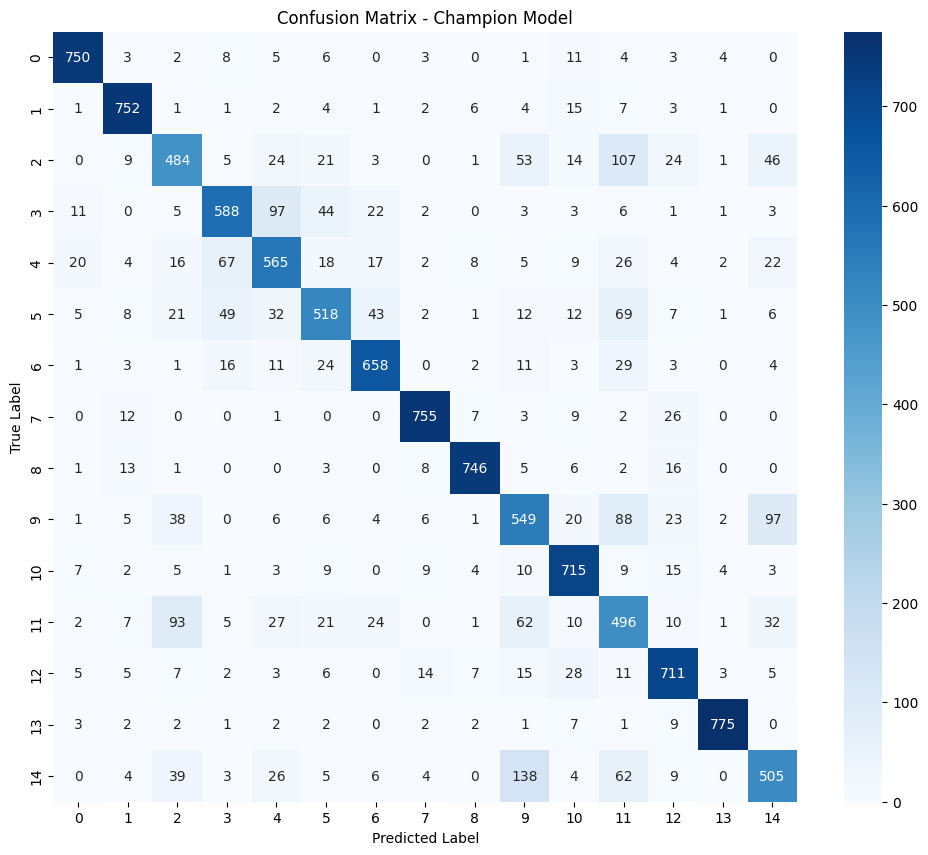

Top 2 Most Confused Pairs:
True Class 14 was predicted as Class 9 -> 138 times
True Class 2 was predicted as Class 11 -> 107 times


In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# 1. Load your best saved weights into the Champion model
model = Champion() # Ensure your CHAMPION_LAYERS are [512, 256, 128]
model.load_state_dict(torch.load('best_model_champion4.pth'))
model.to(device)
model.eval()

all_preds = []
all_targets = []

# 2. Gather all predictions from the validation set
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Champion Model')
plt.show()

# 4. Find the Top 2 Confused Pairs
# Fill diagonal with 0s so we only look at mistakes
np.fill_diagonal(cm, 0)

# Flatten and get the indices of the highest errors
flat_cm = cm.flatten()
top_2_indices = flat_cm.argsort()[-2:][::-1]

print("Top 2 Most Confused Pairs:")
for idx in top_2_indices:
    true_class = idx // 15  # Assuming 15 classes
    pred_class = idx % 15
    mistakes = cm[true_class, pred_class]
    print(f"True Class {true_class} was predicted as Class {pred_class} -> {mistakes} times")

In [70]:
# Added LR Scheduler, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss()

In [71]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion6.pth')
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0
    
    scheduler.step(val_loss_avg)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.001
Epoch 1/40
Train Loss: 1.2583 | Train Acc: 59.42%
Val Loss:   0.8938 | Val Acc:   69.58%
------------------------------
Current Learning Rate: 0.001
Epoch 2/40
Train Loss: 0.9663 | Train Acc: 68.03%
Val Loss:   0.8034 | Val Acc:   72.82%
------------------------------
Current Learning Rate: 0.001
Epoch 3/40
Train Loss: 0.8766 | Train Acc: 71.04%
Val Loss:   0.7586 | Val Acc:   74.27%
------------------------------
Current Learning Rate: 0.001
Epoch 4/40
Train Loss: 0.8137 | Train Acc: 73.04%
Val Loss:   0.7335 | Val Acc:   75.58%
------------------------------
Current Learning Rate: 0.001
Epoch 5/40
Train Loss: 0.7617 | Train Acc: 74.84%
Val Loss:   0.7043 | Val Acc:   76.53%
------------------------------
Current Learning Rate: 0.001
Epoch 6/40
Train Loss: 0.7159 | Train Acc: 76.30%
Val Loss:   0.6976 | Val Acc:   77.10%
------------------------------
Current Learning Rate: 0.001
Epoch 7/40
Train Loss: 0.6832 | Train Acc: 77.21%
Val Loss:   0.6741 | Val Ac

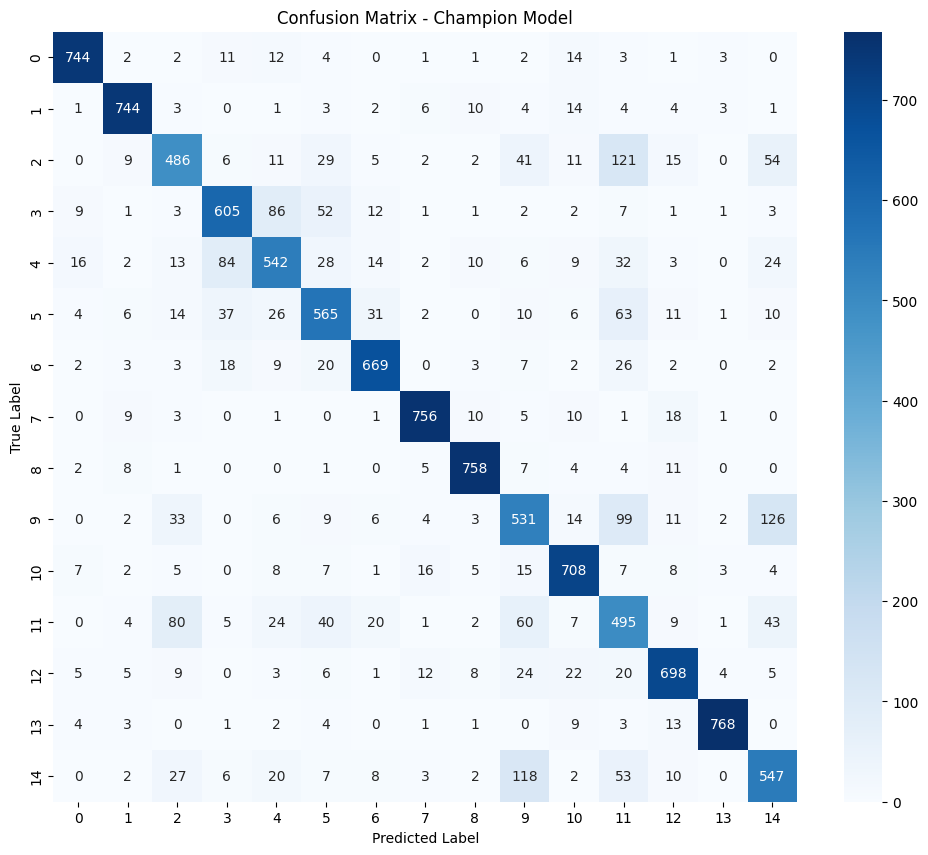

Top 2 Most Confused Pairs:
True Class 9 was predicted as Class 14 -> 126 times
True Class 2 was predicted as Class 11 -> 121 times


In [72]:
model = Champion()
model.load_state_dict(torch.load('best_model_champion6.pth'))
model.to(device)
model.eval()

all_preds = []
all_targets = []

# 2. Gather all predictions from the validation set
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Champion Model')
plt.show()

# 4. Find the Top 2 Confused Pairs
# Fill diagonal with 0s so we only look at mistakes
np.fill_diagonal(cm, 0)

# Flatten and get the indices of the highest errors
flat_cm = cm.flatten()
top_2_indices = flat_cm.argsort()[-2:][::-1]

print("Top 2 Most Confused Pairs:")
for idx in top_2_indices:
    true_class = idx // 15  # Assuming 15 classes
    pred_class = idx % 15
    mistakes = cm[true_class, pred_class]
    print(f"True Class {true_class} was predicted as Class {pred_class} -> {mistakes} times")

In [73]:
# Added label smoothing, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [74]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion7.pth')
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0
    
    scheduler.step(val_loss_avg)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.001
Epoch 1/40
Train Loss: 1.5639 | Train Acc: 59.85%
Val Loss:   1.2796 | Val Acc:   70.30%
------------------------------
Current Learning Rate: 0.001
Epoch 2/40
Train Loss: 1.3492 | Train Acc: 68.49%
Val Loss:   1.2161 | Val Acc:   73.02%
------------------------------
Current Learning Rate: 0.001
Epoch 3/40
Train Loss: 1.2819 | Train Acc: 71.15%
Val Loss:   1.1803 | Val Acc:   73.85%
------------------------------
Current Learning Rate: 0.001
Epoch 4/40
Train Loss: 1.2374 | Train Acc: 73.42%
Val Loss:   1.1584 | Val Acc:   75.20%
------------------------------
Current Learning Rate: 0.001
Epoch 5/40
Train Loss: 1.1996 | Train Acc: 74.75%
Val Loss:   1.1282 | Val Acc:   76.79%
------------------------------
Current Learning Rate: 0.001
Epoch 6/40
Train Loss: 1.1667 | Train Acc: 76.49%
Val Loss:   1.1172 | Val Acc:   77.49%
------------------------------
Current Learning Rate: 0.001
Epoch 7/40
Train Loss: 1.1407 | Train Acc: 77.59%
Val Loss:   1.1085 | Val Ac

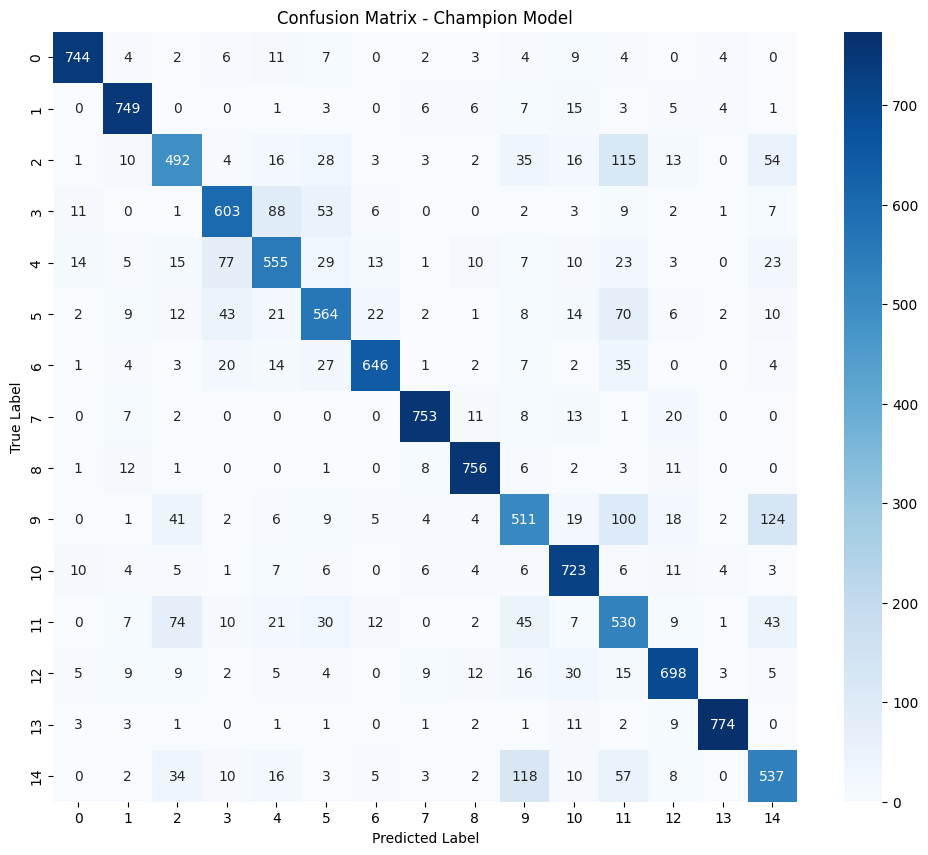

Top 2 Most Confused Pairs:
True Class 9 was predicted as Class 14 -> 124 times
True Class 14 was predicted as Class 9 -> 118 times


In [75]:
model = Champion()
model.load_state_dict(torch.load('best_model_champion7.pth'))
model.to(device)
model.eval()

all_preds = []
all_targets = []

# 2. Gather all predictions from the validation set
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Champion Model')
plt.show()

# 4. Find the Top 2 Confused Pairs
# Fill diagonal with 0s so we only look at mistakes
np.fill_diagonal(cm, 0)

# Flatten and get the indices of the highest errors
flat_cm = cm.flatten()
top_2_indices = flat_cm.argsort()[-2:][::-1]

print("Top 2 Most Confused Pairs:")
for idx in top_2_indices:
    true_class = idx // 15  # Assuming 15 classes
    pred_class = idx % 15
    mistakes = cm[true_class, pred_class]
    print(f"True Class {true_class} was predicted as Class {pred_class} -> {mistakes} times")

In [1]:
import torchvision.transforms as T

# Define a light augmentation pipeline
# Degrees: Rotate between -10 and +10 degrees
# Translate: Shift the image up/down/left/right by up to 10%
augment = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1))
])

In [77]:
# Added data augmentation, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [78]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        inputs_2d = inputs.view(-1, 1, 28, 28)
        
        augmented_2d = augment(inputs_2d)
        
        inputs = augmented_2d.view(-1, 784)
        optimizer.zero_grad()
        
        outputs = model(inputs) 
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion8.pth')
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0
    
    scheduler.step(val_loss_avg)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.001
Epoch 1/40
Train Loss: 1.7937 | Train Acc: 48.82%
Val Loss:   1.3857 | Val Acc:   65.12%
------------------------------
Current Learning Rate: 0.001
Epoch 2/40
Train Loss: 1.5690 | Train Acc: 58.25%
Val Loss:   1.3292 | Val Acc:   67.88%
------------------------------
Current Learning Rate: 0.001
Epoch 3/40
Train Loss: 1.5082 | Train Acc: 60.75%
Val Loss:   1.3118 | Val Acc:   68.53%
------------------------------
Current Learning Rate: 0.001
Epoch 4/40
Train Loss: 1.4774 | Train Acc: 62.16%
Val Loss:   1.2880 | Val Acc:   70.23%
------------------------------
Current Learning Rate: 0.001
Epoch 5/40
Train Loss: 1.4401 | Train Acc: 64.03%
Val Loss:   1.2446 | Val Acc:   71.78%
------------------------------
Current Learning Rate: 0.001
Epoch 6/40
Train Loss: 1.4124 | Train Acc: 65.06%
Val Loss:   1.2085 | Val Acc:   73.17%
------------------------------
Current Learning Rate: 0.001
Epoch 7/40
Train Loss: 1.3887 | Train Acc: 66.28%
Val Loss:   1.1965 | Val Ac

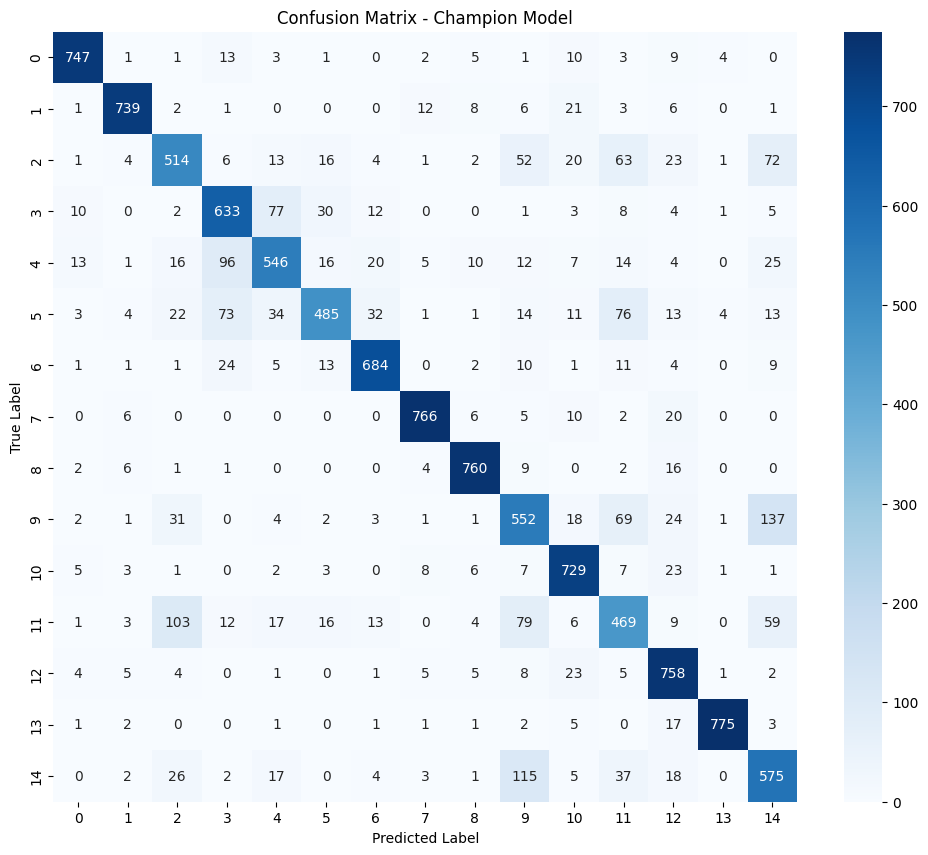

Top 2 Most Confused Pairs:
True Class 9 was predicted as Class 14 -> 137 times
True Class 14 was predicted as Class 9 -> 115 times


In [79]:
model = Champion()
model.load_state_dict(torch.load('best_model_champion8.pth'))
model.to(device)
model.eval()

all_preds = []
all_targets = []

# 2. Gather all predictions from the validation set
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Champion Model')
plt.show()

# 4. Find the Top 2 Confused Pairs
# Fill diagonal with 0s so we only look at mistakes
np.fill_diagonal(cm, 0)

# Flatten and get the indices of the highest errors
flat_cm = cm.flatten()
top_2_indices = flat_cm.argsort()[-2:][::-1]

print("Top 2 Most Confused Pairs:")
for idx in top_2_indices:
    true_class = idx // 15  # Assuming 15 classes
    pred_class = idx % 15
    mistakes = cm[true_class, pred_class]
    print(f"True Class {true_class} was predicted as Class {pred_class} -> {mistakes} times")

In [83]:
# Switched to one cycle LR, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01, 
    epochs=40,
    steps_per_epoch=len(train_loader)
)

In [84]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        inputs_2d = inputs.view(-1, 1, 28, 28)
        
        augmented_2d = augment(inputs_2d)
        
        inputs = augmented_2d.view(-1, 784)
        optimizer.zero_grad()
        
        outputs = model(inputs) 
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        scheduler.step()
    
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion9.pth')
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.0005636283336392083
Epoch 1/40
Train Loss: 1.9452 | Train Acc: 42.72%
Val Loss:   1.4668 | Val Acc:   63.04%
------------------------------
Current Learning Rate: 0.001043357404736189
Epoch 2/40
Train Loss: 1.6430 | Train Acc: 55.10%
Val Loss:   1.3843 | Val Acc:   66.23%
------------------------------
Current Learning Rate: 0.0018064800180818252
Epoch 3/40
Train Loss: 1.5644 | Train Acc: 58.42%
Val Loss:   1.3546 | Val Acc:   66.33%
------------------------------
Current Learning Rate: 0.0028009676396827223
Epoch 4/40
Train Loss: 1.5099 | Train Acc: 60.84%
Val Loss:   1.2902 | Val Acc:   69.31%
------------------------------
Current Learning Rate: 0.003959017622727477
Epoch 5/40
Train Loss: 1.4881 | Train Acc: 62.11%
Val Loss:   1.3122 | Val Acc:   68.15%
------------------------------
Current Learning Rate: 0.0052016758884675315
Epoch 6/40
Train Loss: 1.4455 | Train Acc: 63.92%
Val Loss:   1.2338 | Val Acc:   72.36%
------------------------------
Current Lear

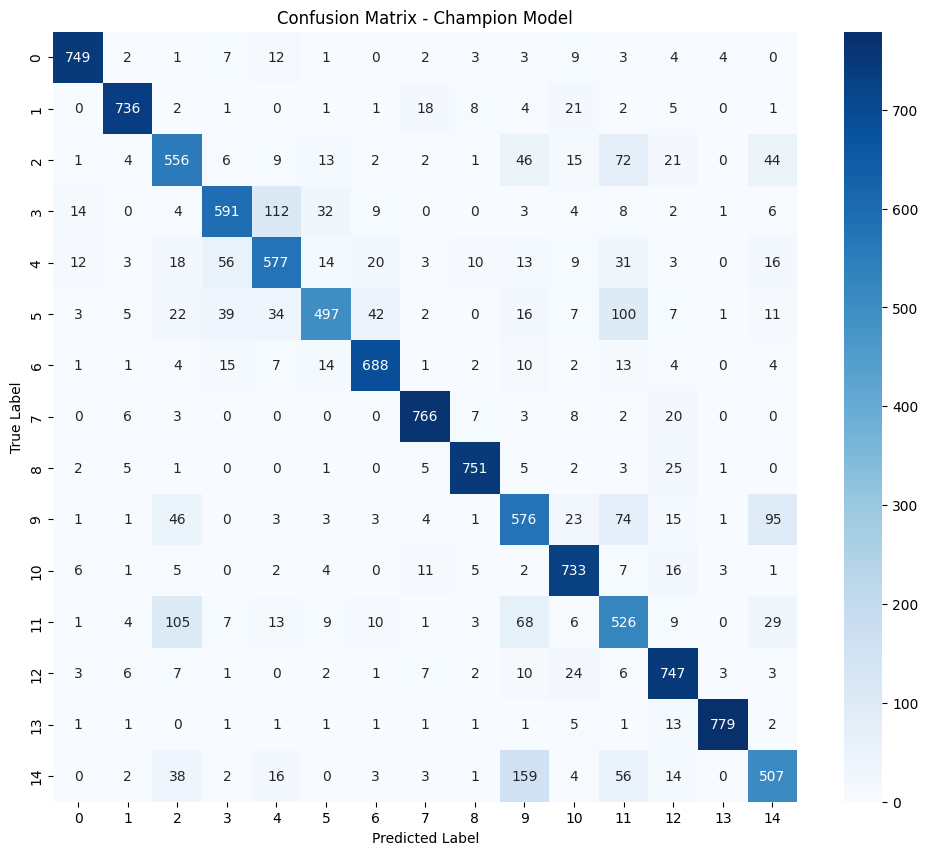

Top 2 Most Confused Pairs:
True Class 14 was predicted as Class 9 -> 159 times
True Class 3 was predicted as Class 4 -> 112 times


In [85]:
model = Champion()
model.load_state_dict(torch.load('best_model_champion9.pth'))
model.to(device)
model.eval()

all_preds = []
all_targets = []

# 2. Gather all predictions from the validation set
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Champion Model')
plt.show()

# 4. Find the Top 2 Confused Pairs
# Fill diagonal with 0s so we only look at mistakes
np.fill_diagonal(cm, 0)

# Flatten and get the indices of the highest errors
flat_cm = cm.flatten()
top_2_indices = flat_cm.argsort()[-2:][::-1]

print("Top 2 Most Confused Pairs:")
for idx in top_2_indices:
    true_class = idx // 15  # Assuming 15 classes
    pred_class = idx % 15
    mistakes = cm[true_class, pred_class]
    print(f"True Class {true_class} was predicted as Class {pred_class} -> {mistakes} times")

In [ ]:
# Added Graduated Dropout (0.2,0.3,0.4), then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01, 
    epochs=40,
    steps_per_epoch=len(train_loader)
)

In [ ]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        inputs_2d = inputs.view(-1, 1, 28, 28)
        
        augmented_2d = augment(inputs_2d)
        
        inputs = augmented_2d.view(-1, 784)
        optimizer.zero_grad()
        
        outputs = model(inputs) 
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        scheduler.step()
    
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion10.pth')
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.0005636283336392083
Epoch 1/40
Train Loss: 1.8554 | Train Acc: 46.68%
Val Loss:   1.4880 | Val Acc:   61.02%
------------------------------
Current Learning Rate: 0.001043357404736189
Epoch 2/40
Train Loss: 1.5720 | Train Acc: 58.16%
Val Loss:   1.3588 | Val Acc:   66.54%
------------------------------
Current Learning Rate: 0.0018064800180818252
Epoch 3/40
Train Loss: 1.5028 | Train Acc: 61.14%
Val Loss:   1.2979 | Val Acc:   69.27%
------------------------------
Current Learning Rate: 0.0028009676396827223
Epoch 4/40
Train Loss: 1.4536 | Train Acc: 63.21%
Val Loss:   1.2680 | Val Acc:   70.26%
------------------------------
Current Learning Rate: 0.003959017622727477
Epoch 5/40
Train Loss: 1.4161 | Train Acc: 64.99%
Val Loss:   1.2304 | Val Acc:   71.49%
------------------------------
Current Learning Rate: 0.0052016758884675315
Epoch 6/40
Train Loss: 1.3764 | Train Acc: 67.13%
Val Loss:   1.2129 | Val Acc:   72.83%
------------------------------
Current Lear

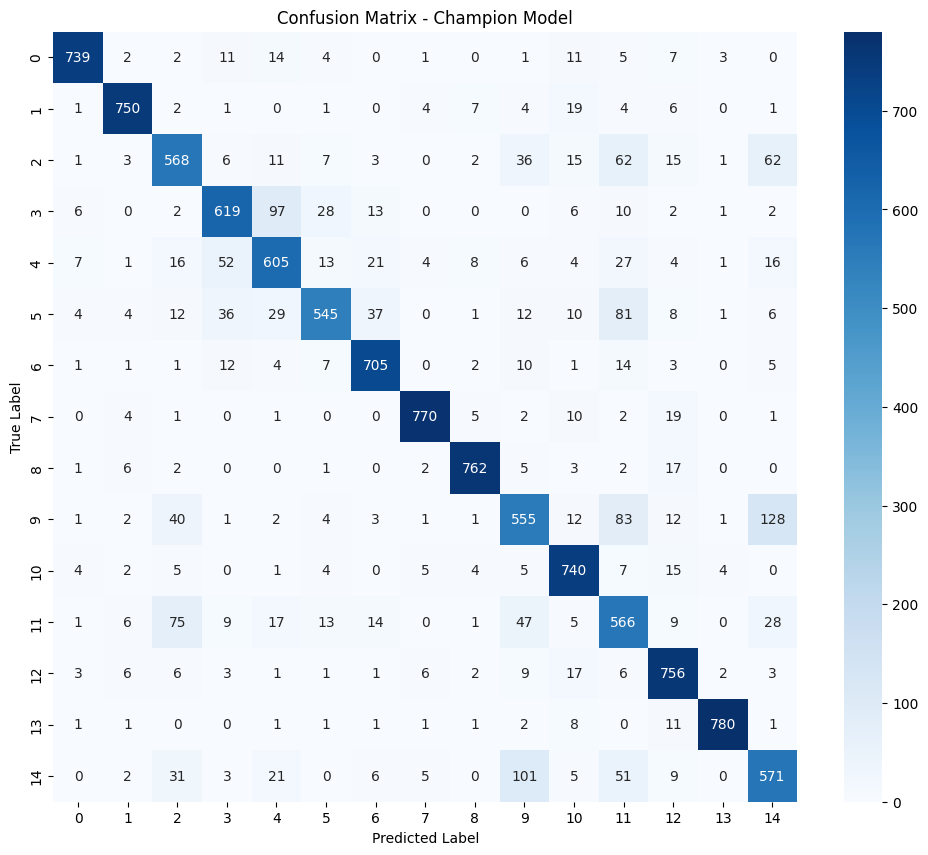

Top 2 Most Confused Pairs:
True Class 9 was predicted as Class 14 -> 128 times
True Class 14 was predicted as Class 9 -> 101 times


In [ ]:
model = Champion()
model.load_state_dict(torch.load('best_model_champion10.pth'))
model.to(device)
model.eval()

all_preds = []
all_targets = []

# 2. Gather all predictions from the validation set
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Champion Model')
plt.show()

# 4. Find the Top 2 Confused Pairs
# Fill diagonal with 0s so we only look at mistakes
np.fill_diagonal(cm, 0)

# Flatten and get the indices of the highest errors
flat_cm = cm.flatten()
top_2_indices = flat_cm.argsort()[-2:][::-1]

print("Top 2 Most Confused Pairs:")
for idx in top_2_indices:
    true_class = idx // 15  # Assuming 15 classes
    pred_class = idx % 15
    mistakes = cm[true_class, pred_class]
    print(f"True Class {true_class} was predicted as Class {pred_class} -> {mistakes} times")

In [90]:
# Added weight decay, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01, 
    epochs=40,
    steps_per_epoch=len(train_loader)
)

In [91]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        inputs_2d = inputs.view(-1, 1, 28, 28)
        
        augmented_2d = augment(inputs_2d)
        
        inputs = augmented_2d.view(-1, 784)
        optimizer.zero_grad()
        
        outputs = model(inputs) 
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        scheduler.step()
    
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion11.pth')
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.0005636283336392083
Epoch 1/40
Train Loss: 1.8690 | Train Acc: 46.68%
Val Loss:   1.4236 | Val Acc:   65.34%
------------------------------
Current Learning Rate: 0.001043357404736189
Epoch 2/40
Train Loss: 1.5675 | Train Acc: 58.56%
Val Loss:   1.3297 | Val Acc:   68.31%
------------------------------
Current Learning Rate: 0.0018064800180818252
Epoch 3/40
Train Loss: 1.5018 | Train Acc: 61.33%
Val Loss:   1.3123 | Val Acc:   68.08%
------------------------------
Current Learning Rate: 0.0028009676396827223
Epoch 4/40
Train Loss: 1.4434 | Train Acc: 63.72%
Val Loss:   1.2497 | Val Acc:   71.36%
------------------------------
Current Learning Rate: 0.003959017622727477
Epoch 5/40
Train Loss: 1.4200 | Train Acc: 65.12%
Val Loss:   1.2217 | Val Acc:   72.62%
------------------------------
Current Learning Rate: 0.0052016758884675315
Epoch 6/40
Train Loss: 1.3748 | Train Acc: 67.07%
Val Loss:   1.2004 | Val Acc:   73.26%
------------------------------
Current Lear

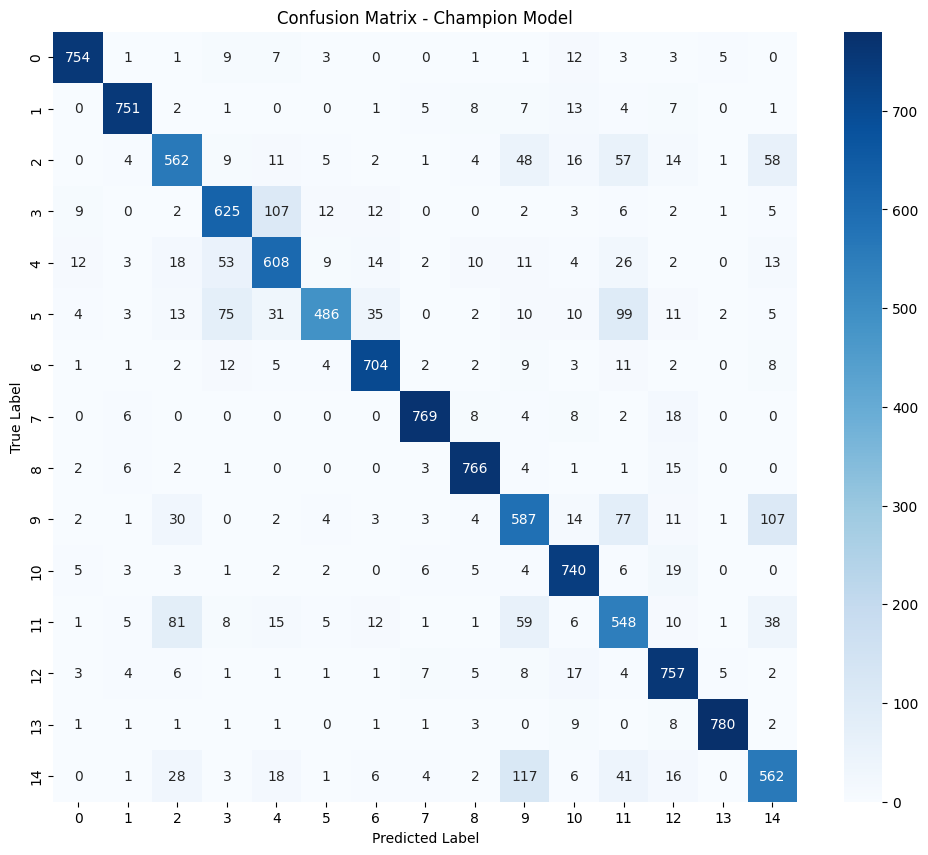

Top 2 Most Confused Pairs:
True Class 14 was predicted as Class 9 -> 117 times
True Class 9 was predicted as Class 14 -> 107 times


In [92]:
model = Champion()
model.load_state_dict(torch.load('best_model_champion11.pth'))
model.to(device)
model.eval()

all_preds = []
all_targets = []

# 2. Gather all predictions from the validation set
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Champion Model')
plt.show()

# 4. Find the Top 2 Confused Pairs
# Fill diagonal with 0s so we only look at mistakes
np.fill_diagonal(cm, 0)

# Flatten and get the indices of the highest errors
flat_cm = cm.flatten()
top_2_indices = flat_cm.argsort()[-2:][::-1]

print("Top 2 Most Confused Pairs:")
for idx in top_2_indices:
    true_class = idx // 15  # Assuming 15 classes
    pred_class = idx % 15
    mistakes = cm[true_class, pred_class]
    print(f"True Class {true_class} was predicted as Class {pred_class} -> {mistakes} times")

In [11]:
# Adjusted batch size to 256 and undo weight decay, then will experiment with other changes if needed.
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
model = Champion().apply(initialize_weights).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.05, 
    epochs=40,
    steps_per_epoch=len(train_loader)
)

In [12]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        inputs_2d = inputs.view(-1, 1, 28, 28)
        
        augmented_2d = augment(inputs_2d)
        
        inputs = augmented_2d.view(-1, 784)
        optimizer.zero_grad()
        
        outputs = model(inputs) 
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        scheduler.step()
    
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion12.pth')
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.0028185014818429624
Epoch 1/40
Train Loss: 2.5851 | Train Acc: 38.07%
Val Loss:   1.4798 | Val Acc:   60.38%
------------------------------
Current Learning Rate: 0.005218177204390259
Epoch 2/40
Train Loss: 1.7010 | Train Acc: 53.18%
Val Loss:   1.3903 | Val Acc:   64.74%
------------------------------
Current Learning Rate: 0.009035348989737929
Epoch 3/40
Train Loss: 1.5593 | Train Acc: 58.31%
Val Loss:   1.3448 | Val Acc:   66.88%
------------------------------
Current Learning Rate: 0.014009653440989617
Epoch 4/40
Train Loss: 1.4743 | Train Acc: 61.82%
Val Loss:   1.2829 | Val Acc:   69.97%
------------------------------
Current Learning Rate: 0.01980180092777135
Epoch 5/40
Train Loss: 1.4237 | Train Acc: 63.98%
Val Loss:   1.2638 | Val Acc:   69.92%
------------------------------
Current Learning Rate: 0.0260167180083345
Epoch 6/40
Train Loss: 1.3895 | Train Acc: 65.64%
Val Loss:   1.2273 | Val Acc:   71.53%
------------------------------
Current Learning R

In [13]:
count_parameters(model)

1866767

In [ ]:
def generate_final_submission(model, test_loader, augment_fn, num_passes=5):
    model.eval() 
    all_predictions = []
    
    print(f"Starting TTA Inference with {num_passes} passes...")
    
    with torch.no_grad():
        for i, inputs in enumerate(test_loader):
            # Handle TensorDataset wrapping
            if isinstance(inputs, (list, tuple)):
                inputs = inputs[0]
            
            inputs = inputs.to(device)
            inputs_2d = inputs.view(-1, 1, 28, 28)
            
            # Accumulate raw scores (logits)
            accumulated_logits = torch.zeros(inputs.size(0), 15).to(device)
            
            # Pass 1: Original image
            accumulated_logits += model(inputs)
            
            # Passes 2-N: Augmented versions
            for _ in range(num_passes - 1):
                aug_2d = augment_fn(inputs_2d)
                aug_flat = aug_2d.view(-1, 784)
                accumulated_logits += model(aug_flat)
                
            # Average and find the most confident class
            preds = torch.argmax(accumulated_logits, dim=1)
            all_predictions.extend(preds.cpu().numpy())
            
            if (i + 1) % 50 == 0:
                print(f"Processed {len(all_predictions)} test samples...")

    # Join with commas: 0, 1, 0, 12...
    csv_string = ",".join(map(str, all_predictions))
    
    with open("final_submission.txt", "w") as f:
        f.write(csv_string)
        
    print("\nSubmission string generated successfully!")
    print(f"Total Predictions: {len(all_predictions)}")
    print("Check 'final_submission.txt' for your string.")
    print(csv_string)
# 1. Initialize model with your [1024, 512, 256] structure
model = Champion() 

# 2. Load the best weights from your peak at Epoch 38
model.load_state_dict(torch.load('best_model_champion12.pth'))
model.to(device)

# 3. Generate the file (Ensure test_loader has shuffle=False!)
generate_final_submission(model, test_loader, augment, num_passes=5)

Starting TTA Inference with 5 passes...
Processed 6400 test samples...
Processed 12800 test samples...

Submission string generated successfully!
Total Predictions: 15000
Check 'final_submission.txt' for your string.
6,11,5,8,0,1,11,9,14,8,9,7,11,11,13,8,13,12,11,3,13,6,14,8,0,13,13,2,6,5,14,11,1,12,13,5,11,5,8,2,12,8,0,2,13,1,14,14,10,1,3,11,0,9,11,11,11,6,10,9,14,6,1,2,0,12,11,12,4,11,4,6,3,14,13,6,5,6,11,11,10,13,6,4,12,0,0,2,14,11,0,7,1,14,3,6,3,12,9,10,14,12,1,4,5,9,7,4,14,11,9,1,1,13,12,2,1,7,9,0,4,7,9,2,13,13,7,14,3,4,5,6,0,8,11,11,11,12,1,13,10,2,1,9,1,12,7,2,3,0,4,14,1,12,6,10,0,4,9,6,0,9,5,13,9,13,5,9,1,5,12,10,4,4,13,7,14,6,7,11,2,13,10,3,12,3,8,6,11,1,9,14,8,6,0,4,1,5,5,10,6,14,10,1,13,1,1,10,5,7,14,11,1,11,6,2,6,3,8,1,1,4,12,12,9,11,13,14,4,0,11,6,4,14,1,3,10,0,11,4,9,2,4,12,4,9,5,0,6,7,6,5,7,1,13,5,1,9,0,4,13,0,7,4,6,4,12,12,3,7,13,11,11,4,10,8,12,8,6,6,1,7,12,12,0,3,14,4,12,4,6,6,2,0,9,12,9,6,2,8,5,12,3,0,6,11,11,7,13,8,12,13,12,1,5,3,9,10,14,13,0,9,12,11,7,9,3,10,11,12,

In [2]:
def initialize_weights(m):
    if isinstance(m, nn.Linear):
        # Apply Kaiming Normal initialization to weights
        # non-linearity='leaky_relu' or 'relu' is standard for GELU as well
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        
        # Initialize biases to zero
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    
    elif isinstance(m, nn.BatchNorm1d):
        # BatchNorm layers should be initialized to 1 for weight and 0 for bias
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

In [149]:
# Ensemble Training
num_models = 5
ensemble_paths3 = []
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
for i in range(num_models):
    print(f"\n--- Training Model {i+1}/{num_models} ---")
    
    # Re-initialize model, optimizer, and scheduler for each run
    model = Champion(hidden_layers=[512, 512, 256]).to(device) 
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.01)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.02, epochs=40, steps_per_epoch=len(train_loader)
    )
    
    best_val_acc = 0.0
    save_path = f'model_ensemble_{i}_init.pth'
    
    for epoch in range(40):
        model.train()
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            # Apply your Data Augmentation injection here
            inputs = augment(inputs.view(-1, 1, 28, 28)).view(-1, 784)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            scheduler.step()

        # Simple validation check to save the best version of THIS model
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == targets).sum().item()
                total += targets.size(0)
        
        val_acc = correct / total
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), save_path)
            
    print(f"Model {i+1} Best Val Acc: {best_val_acc*100:.2f}% at epoch {best_epoch}")
    print(f"Number of parameters of model {i+1}: {count_parameters(model)}")
    ensemble_paths3.append(save_path)


--- Training Model 1/5 ---
Model 1 Best Val Acc: 84.68% at epoch 38
Number of parameters of model 1: 802319

--- Training Model 2/5 ---
Model 2 Best Val Acc: 84.64% at epoch 40
Number of parameters of model 2: 802319

--- Training Model 3/5 ---
Model 3 Best Val Acc: 84.76% at epoch 38
Number of parameters of model 3: 802319

--- Training Model 4/5 ---
Model 4 Best Val Acc: 84.75% at epoch 39
Number of parameters of model 4: 802319

--- Training Model 5/5 ---
Model 5 Best Val Acc: 84.06% at epoch 39
Number of parameters of model 5: 802319


In [130]:
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

In [150]:
def validate_ensemble_tta(models, val_loader, augment_fn, num_tta_passes=10):
    for m in models: m.eval()
    
    val_correct = 0
    val_total = 0
    
    print(f"Running Ensemble TTA on Validation ({num_tta_passes} passes)...")
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            inputs_2d = inputs.view(-1, 1, 28, 28)
            
            # Accumulated logits for the whole batch
            combined_logits = torch.zeros(inputs.size(0), 15).to(device)
            
            for m in models:
                # 1. Original View
                combined_logits += m(inputs)
                
                # 2. Augmented Views
                for _ in range(num_tta_passes - 1):
                    aug_flat = augment_fn(inputs_2d).view(-1, 784)
                    combined_logits += m(aug_flat)
            
            # Take the final vote
            preds = torch.argmax(combined_logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    final_val_acc = val_correct / val_total
    print(f"\nFinal Ensemble + TTA Validation Accuracy: {final_val_acc*100:.2f}%")
    return final_val_acc

# Run the check
# 'models' should be your list of 5 loaded Champion models
# models = []
# for path in ensemble_paths:
#     m = Champion(hidden_layers=[512, 512, 256]).to(device)
#     m.load_state_dict(torch.load(path))
#     models.append(m)
# validate_ensemble_tta(models, val_loader, augment, num_tta_passes=10)
# models = []
# for path in ensemble_paths2:
#     m = Champion(hidden_layers=[512, 512, 256]).to(device)
#     m.load_state_dict(torch.load(path))
#     models.append(m)
# validate_ensemble_tta(models, val_loader, augment, num_tta_passes=10)
models = []
for path in ensemble_paths3:
    m = Champion(hidden_layers=[512, 512, 256]).to(device)
    m.load_state_dict(torch.load(path))
    models.append(m)
validate_ensemble_tta(models, val_loader, augment, num_tta_passes=10)

Running Ensemble TTA on Validation (10 passes)...

Final Ensemble + TTA Validation Accuracy: 84.08%


0.8408333333333333

In [152]:
def generate_ensemble_tta_submission(model_paths, test_loader, augment_fn, num_tta_passes=10):
    models = []
    for path in model_paths:
        m = Champion(hidden_layers=[512, 512, 256]).to(device)
        m.load_state_dict(torch.load(path))
        m.eval()
        models.append(m)
    
    all_predictions = []
    with torch.no_grad():
        for inputs in test_loader:
            if isinstance(inputs, (list, tuple)): inputs = inputs[0]
            inputs = inputs.to(device)
            inputs_2d = inputs.view(-1, 1, 28, 28)
            
            # Sum logits from ALL models and ALL TTA passes
            combined_logits = torch.zeros(inputs.size(0), 15).to(device)
            
            for m in models:
                # Original pass
                combined_logits += m(inputs)
                # TTA passes
                for _ in range(num_tta_passes - 1):
                    aug_flat = augment_fn(inputs_2d).view(-1, 784)
                    combined_logits += m(aug_flat)
            
            preds = torch.argmax(combined_logits, dim=1)
            all_predictions.extend(preds.cpu().numpy())

    csv_string = ",".join(map(str, all_predictions))
    with open("ensemble_submission.txt", "w") as f:
        f.write(csv_string)
    print("Ensemble TTA submission generated!")
    print(csv_string)

# Run it!
generate_ensemble_tta_submission(ensemble_paths3, test_loader, augment)

Ensemble TTA submission generated!
6,11,5,8,0,1,11,9,14,8,9,7,11,11,13,8,13,12,11,3,13,6,14,8,0,13,13,2,6,5,14,11,1,12,13,5,11,5,8,2,12,8,0,2,13,1,11,9,10,1,3,11,0,11,11,11,11,6,10,9,9,6,7,2,0,12,11,12,4,11,4,6,3,14,13,6,5,6,11,11,10,13,6,4,12,0,0,2,14,11,0,7,1,14,3,6,3,12,9,10,14,12,1,4,5,9,7,4,11,11,9,1,1,13,12,2,1,7,9,0,4,7,14,2,13,13,7,14,3,4,5,3,0,8,9,11,11,12,1,13,10,2,1,9,1,12,7,2,3,0,4,14,1,12,6,8,0,4,9,6,0,9,5,13,9,13,11,9,1,5,12,10,4,4,13,7,14,6,7,11,2,13,10,3,12,3,8,6,11,1,9,14,8,6,0,4,1,5,5,10,6,14,10,1,13,1,1,10,5,7,14,11,1,11,6,2,6,4,8,1,1,4,7,12,9,11,13,14,4,0,11,6,4,14,1,3,10,0,11,4,9,2,4,12,4,9,5,0,6,7,6,5,7,1,13,5,1,9,0,4,13,0,7,4,6,4,12,12,3,7,13,9,11,4,10,8,12,8,6,6,1,7,12,12,0,3,14,4,12,4,6,6,2,0,9,12,9,6,2,8,5,12,3,0,6,11,11,7,13,8,12,13,12,1,5,3,9,10,14,13,0,9,12,11,7,9,0,10,11,12,13,12,6,3,2,14,7,8,10,1,11,10,2,1,10,14,12,14,0,7,7,0,10,7,3,7,12,1,7,12,2,13,4,11,5,14,11,8,7,11,12,11,4,13,1,14,4,2,0,13,9,3,10,9,6,0,11,10,10,2,2,5,14,11,3,11,13,10,4,13,9,4,8,7,13,9

In [15]:
model = Champion(hidden_layers=[512, 512, 256]).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.05, 
    epochs=40,
    steps_per_epoch=len(train_loader)
)

In [16]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        inputs_2d = inputs.view(-1, 1, 28, 28)
        
        augmented_2d = augment(inputs_2d)
        
        inputs = augmented_2d.view(-1, 784)
        optimizer.zero_grad()
        
        outputs = model(inputs) 
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        scheduler.step()
    
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion13.pth')
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.0028185014818429624
Epoch 1/40
Train Loss: 2.1834 | Train Acc: 42.11%
Val Loss:   1.4514 | Val Acc:   64.12%
------------------------------
Current Learning Rate: 0.005218177204390259
Epoch 2/40
Train Loss: 1.6328 | Train Acc: 55.50%
Val Loss:   1.3623 | Val Acc:   65.76%
------------------------------
Current Learning Rate: 0.009035348989737929
Epoch 3/40
Train Loss: 1.5271 | Train Acc: 59.66%
Val Loss:   1.3011 | Val Acc:   69.39%
------------------------------
Current Learning Rate: 0.014009653440989617
Epoch 4/40
Train Loss: 1.4704 | Train Acc: 61.92%
Val Loss:   1.2660 | Val Acc:   71.40%
------------------------------
Current Learning Rate: 0.01980180092777135
Epoch 5/40
Train Loss: 1.4167 | Train Acc: 64.20%
Val Loss:   1.2342 | Val Acc:   72.35%
------------------------------
Current Learning Rate: 0.0260167180083345
Epoch 6/40
Train Loss: 1.3851 | Train Acc: 65.52%
Val Loss:   1.2123 | Val Acc:   73.13%
------------------------------
Current Learning R

In [17]:
model = Champion(hidden_layers=[512, 512, 256]).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.05, 
    epochs=40,
    steps_per_epoch=len(train_loader)
)

In [18]:
# augment1 = T.Compose([
#     T.RandomRotation(degrees=10),
#     T.RandomAffine(degrees=0, translate=(0.1, 0.1))
# ])
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        inputs_2d = inputs.view(-1, 1, 28, 28)
        
        augmented_2d = augment(inputs_2d)
        
        inputs = augmented_2d.view(-1, 784)
        optimizer.zero_grad()
        
        outputs = model(inputs) 
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        scheduler.step()
    
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion13.pth')
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.0028185014818429624
Epoch 1/40
Train Loss: 1.4162 | Train Acc: 64.35%
Val Loss:   1.2557 | Val Acc:   70.53%
------------------------------
Current Learning Rate: 0.005218177204390259
Epoch 2/40
Train Loss: 1.2464 | Train Acc: 71.48%
Val Loss:   1.2257 | Val Acc:   72.04%
------------------------------
Current Learning Rate: 0.009035348989737929
Epoch 3/40
Train Loss: 1.1932 | Train Acc: 73.98%
Val Loss:   1.2042 | Val Acc:   73.19%
------------------------------
Current Learning Rate: 0.014009653440989617
Epoch 4/40
Train Loss: 1.1404 | Train Acc: 76.19%
Val Loss:   1.1665 | Val Acc:   75.28%
------------------------------
Current Learning Rate: 0.01980180092777135
Epoch 5/40
Train Loss: 1.0966 | Train Acc: 78.06%
Val Loss:   1.1650 | Val Acc:   75.12%
------------------------------
Current Learning Rate: 0.0260167180083345
Epoch 6/40
Train Loss: 1.0756 | Train Acc: 78.90%
Val Loss:   1.1437 | Val Acc:   75.76%
------------------------------
Current Learning R

## Final Champion

In [65]:
class ChampionFinal(nn.Module):
  def __init__(self, input_size=784, num_classes=15, hidden_layers=CHAMPION_LAYERS):
    super(ChampionFinal, self).__init__()
    layers = [nn.Flatten()]
    current_dim = input_size
    for h_dim in hidden_layers:
        layers.append(nn.Linear(current_dim, h_dim))
        # layers.append(nn.BatchNorm1d(h_dim)) # Iteration 3 addition
        layers.append(nn.LayerNorm(h_dim)) # Final experimentation
        layers.append(nn.GELU()) # Iteration 4 addition
        # if h_dim == 1024:
        layers.append(nn.Dropout(0.1))
        # if h_dim == 512:
        #     layers.append(nn.Dropout(0.2))
        # if h_dim == 256:
        #   layers.append(nn.Dropout(0.3))
        # if h_dim == 128:
        #   layers.append(nn.Dropout(0.4))
        current_dim = h_dim
    layers.append(nn.Linear(current_dim, num_classes))
    self.network = nn.Sequential(*layers)

  def forward(self, x):
    return self.network(x)

In [34]:
model = ChampionFinal(hidden_layers=[512, 512, 256]).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.05, 
    epochs=40,
    steps_per_epoch=len(train_loader)
)

In [ ]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        inputs_2d = inputs.view(-1, 1, 28, 28)
        
        augmented_2d = augment(inputs_2d)
        
        inputs = augmented_2d.view(-1, 784)
        optimizer.zero_grad()
        
        outputs = model(inputs) 
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        scheduler.step()
    
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_finalchampion_layerNorm_2.pth')
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.0028185014818429624
Epoch 1/40
Train Loss: 1.6557 | Train Acc: 53.01%
Val Loss:   1.3851 | Val Acc:   65.19%
------------------------------
Current Learning Rate: 0.005218177204390259
Epoch 2/40
Train Loss: 1.4700 | Train Acc: 61.39%
Val Loss:   1.3180 | Val Acc:   67.92%
------------------------------
Current Learning Rate: 0.009035348989737929
Epoch 3/40
Train Loss: 1.4194 | Train Acc: 63.67%
Val Loss:   1.2587 | Val Acc:   70.09%
------------------------------
Current Learning Rate: 0.014009653440989617
Epoch 4/40
Train Loss: 1.3607 | Train Acc: 66.28%
Val Loss:   1.2430 | Val Acc:   71.91%
------------------------------
Current Learning Rate: 0.01980180092777135
Epoch 5/40
Train Loss: 1.3276 | Train Acc: 67.93%
Val Loss:   1.2034 | Val Acc:   72.96%
------------------------------
Current Learning Rate: 0.0260167180083345
Epoch 6/40
Train Loss: 1.3249 | Train Acc: 67.80%
Val Loss:   1.2098 | Val Acc:   73.07%
------------------------------
Current Learning R

In [67]:
count_parameters(model)

802319

In [64]:
model = ChampionFinal(hidden_layers=[512, 512, 256]).to(device)
model.load_state_dict(torch.load('best_model_finalchampion_layerNorm_2.pth'))
model.eval()

ChampionFinal(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): GELU(approximate='none')
    (4): Dropout(p=0.05, inplace=False)
    (5): Linear(in_features=512, out_features=512, bias=True)
    (6): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.05, inplace=False)
    (9): Linear(in_features=512, out_features=256, bias=True)
    (10): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (11): GELU(approximate='none')
    (12): Dropout(p=0.05, inplace=False)
    (13): Linear(in_features=256, out_features=15, bias=True)
  )
)

In [66]:
def generate_final_submission(model, test_loader, augment_fn, num_passes=5):
    model.eval() 
    all_predictions = []
    
    print(f"Starting TTA Inference with {num_passes} passes...")
    
    with torch.no_grad():
        for i, inputs in enumerate(test_loader):
            # Handle TensorDataset wrapping
            if isinstance(inputs, (list, tuple)):
                inputs = inputs[0]
            
            inputs = inputs.to(device)
            inputs_2d = inputs.view(-1, 1, 28, 28)
            
            # Accumulate raw scores (logits)
            accumulated_logits = torch.zeros(inputs.size(0), 15).to(device)
            
            # Pass 1: Original image
            accumulated_logits += model(inputs)
            
            # Passes 2-N: Augmented versions
            for _ in range(num_passes - 1):
                aug_2d = augment_fn(inputs_2d)
                aug_flat = aug_2d.view(-1, 784)
                accumulated_logits += model(aug_flat)
                
            # Average and find the most confident class
            preds = torch.argmax(accumulated_logits, dim=1)
            all_predictions.extend(preds.cpu().numpy())
            
            if (i + 1) % 50 == 0:
                print(f"Processed {len(all_predictions)} test samples...")

    # Join with commas: 0, 1, 0, 12...
    csv_string = ",".join(map(str, all_predictions))
    
    with open("final_submission.txt", "w") as f:
        f.write(csv_string)
        
    print("\nSubmission string generated successfully!")
    print(f"Total Predictions: {len(all_predictions)}")
    print("Check 'final_submission.txt' for your string.")
    print(csv_string)

# 3. Generate the file (Ensure test_loader has shuffle=False!)
generate_final_submission(model, test_loader, augment, num_passes=15)

Starting TTA Inference with 15 passes...
Processed 12800 test samples...

Submission string generated successfully!
Total Predictions: 15000
Check 'final_submission.txt' for your string.
6,11,5,13,0,1,11,9,14,8,9,7,11,11,13,8,13,12,11,5,13,6,14,8,0,13,13,2,6,5,14,11,1,12,13,5,9,5,8,2,12,8,0,2,13,1,6,14,10,1,5,11,0,11,5,11,11,6,10,9,14,6,7,2,0,12,11,12,4,11,4,6,3,14,13,6,5,6,2,11,10,13,6,4,12,0,0,2,14,11,0,7,1,14,5,6,3,12,9,10,14,12,1,4,5,9,7,4,14,11,9,1,1,13,12,2,1,7,9,0,4,7,9,2,13,13,7,14,3,4,5,6,0,8,9,11,11,12,0,13,10,2,1,14,1,12,7,2,3,0,2,14,1,12,6,8,0,4,9,6,0,9,5,13,9,13,5,6,1,5,12,10,4,4,13,7,14,6,7,9,2,13,10,3,12,3,8,6,11,1,9,14,8,6,0,4,1,5,5,2,5,14,10,1,13,1,1,10,5,7,14,5,1,9,6,2,6,3,8,1,1,4,7,8,9,11,13,14,4,0,11,6,4,14,1,3,10,0,11,4,9,2,4,12,4,14,5,0,6,7,6,5,7,1,13,5,1,9,0,4,13,0,7,4,6,4,12,12,3,7,13,11,2,3,0,1,12,8,6,6,1,7,12,12,0,3,14,4,12,6,6,6,2,0,9,12,9,6,3,8,5,12,3,0,6,11,11,7,13,8,12,13,9,1,5,3,14,10,14,13,0,9,12,11,7,9,0,10,11,12,13,12,6,3,2,14,7,8,10,1,11,10,2,1,10,14,

## Plotting figures

Plot successfully saved as 'final_champion.png'.


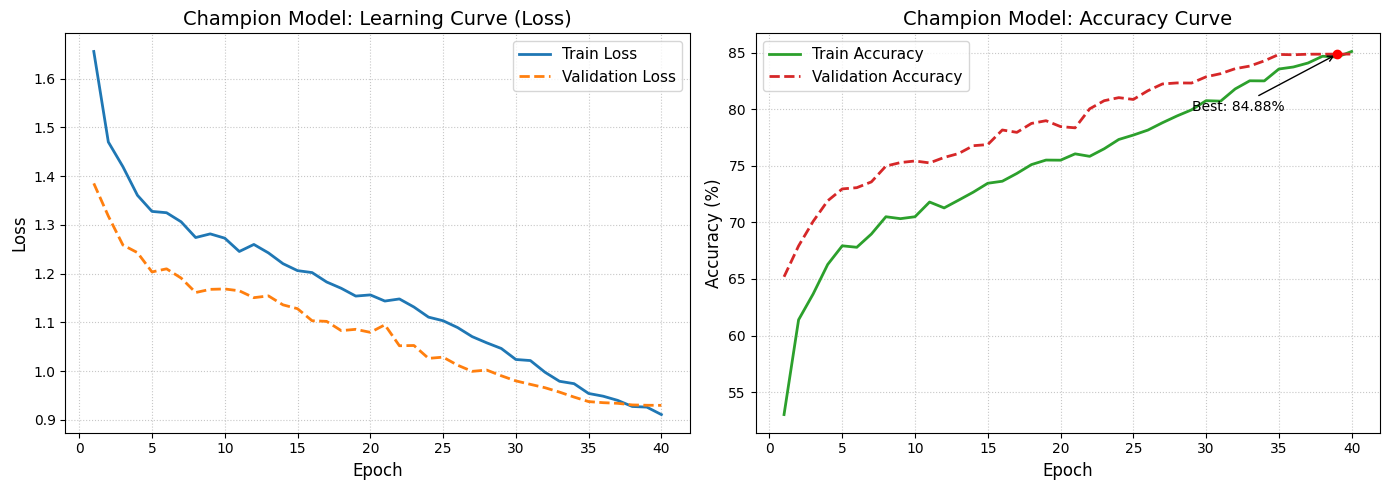

In [74]:
# Final Champion Model: Learning Curves
import matplotlib.pyplot as plt

# Extracted metrics from your 40-epoch log
epochs = list(range(1, 41))

train_loss = [1.6557, 1.4700, 1.4194, 1.3607, 1.3276, 1.3249, 1.3063, 1.2740, 1.2815, 1.2727, 
              1.2454, 1.2598, 1.2425, 1.2204, 1.2061, 1.2021, 1.1828, 1.1699, 1.1539, 1.1563, 
              1.1437, 1.1480, 1.1314, 1.1107, 1.1033, 1.0893, 1.0707, 1.0580, 1.0464, 1.0238, 
              1.0216, 0.9977, 0.9791, 0.9742, 0.9541, 0.9485, 0.9399, 0.9274, 0.9261, 0.9108]

val_loss = [1.3851, 1.3180, 1.2587, 1.2430, 1.2034, 1.2098, 1.1909, 1.1612, 1.1677, 1.1685, 
            1.1647, 1.1506, 1.1543, 1.1359, 1.1280, 1.1033, 1.1020, 1.0830, 1.0857, 1.0795, 
            1.0949, 1.0520, 1.0525, 1.0261, 1.0286, 1.0121, 0.9995, 1.0021, 0.9904, 0.9799, 
            0.9728, 0.9659, 0.9569, 0.9467, 0.9374, 0.9352, 0.9339, 0.9306, 0.9299, 0.9297]

train_acc = [53.01, 61.39, 63.67, 66.28, 67.93, 67.80, 68.97, 70.50, 70.33, 70.50, 
             71.80, 71.28, 71.97, 72.67, 73.46, 73.64, 74.33, 75.11, 75.51, 75.50, 
             76.06, 75.84, 76.51, 77.33, 77.72, 78.16, 78.81, 79.41, 79.95, 80.76, 
             80.72, 81.80, 82.52, 82.51, 83.56, 83.74, 84.09, 84.69, 84.62, 85.11]

val_acc = [65.19, 67.92, 70.09, 71.91, 72.96, 73.07, 73.58, 74.98, 75.29, 75.43, 
           75.26, 75.74, 76.09, 76.78, 76.88, 78.17, 77.96, 78.75, 78.99, 78.47, 
           78.36, 80.04, 80.76, 81.03, 80.87, 81.64, 82.24, 82.33, 82.32, 82.87, 
           83.15, 83.59, 83.82, 84.28, 84.85, 84.82, 84.87, 84.87, 84.88, 84.88]

# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Curve
ax1.plot(epochs, train_loss, label='Train Loss', color='tab:blue', linewidth=2)
ax1.plot(epochs, val_loss, label='Validation Loss', color='tab:orange', linewidth=2, linestyle='--')
ax1.set_title('Champion Model: Learning Curve (Loss)', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.7)

# Plot 2: Accuracy Curve
ax2.plot(epochs, train_acc, label='Train Accuracy', color='tab:green', linewidth=2)
ax2.plot(epochs, val_acc, label='Validation Accuracy', color='tab:red', linewidth=2, linestyle='--')
ax2.set_title('Champion Model: Accuracy Curve', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.7)

# Highlight the best epoch (Epoch 39)
best_epoch = 39
best_acc = 84.88
ax2.scatter(best_epoch, best_acc, color='red', zorder=5)
ax2.annotate(f'Best: {best_acc}%', 
             xy=(best_epoch, best_acc), 
             xytext=(best_epoch - 10, best_acc - 5),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10)

# Adjust layout and save the image
plt.tight_layout()
plt.savefig('final_champion.pdf', dpi=300, bbox_inches='tight')
print("Plot successfully saved as 'final_champion.png'.")

# Display the plot
plt.show()

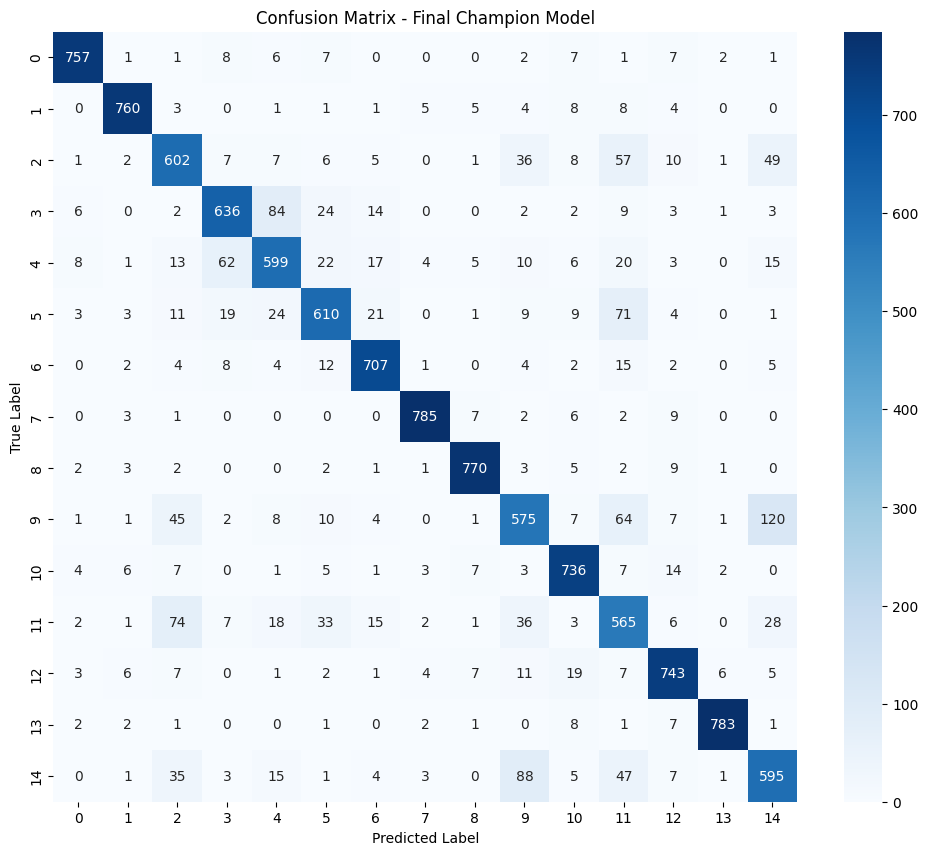

Top 5 Most Confused Pairs:
True Class pizza:9 was predicted as Class wheel:14 (120 times)
True Class wheel:14 was predicted as Class pizza:9 (88 times)
True Class clock:3 was predicted as Class compass:4 (84 times)
True Class soccerball:11 was predicted as Class basketball:2 (74 times)
True Class cookie:5 was predicted as Class soccerball:11 (71 times)


In [83]:
# Final Champion Model: Confusion Matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
model = ChampionFinal(hidden_layers=[512, 512, 256]).to(device)
model.load_state_dict(torch.load('best_model_finalchampion_layerNorm_2.pth'))
model.eval()
all_preds = []
all_targets = []
# 2. Gather all predictions from the validation set
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Final Champion Model')
plt.savefig('final_champion_confusion_matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()
# 4. Find the Top 2 Confused Pairs
# Fill diagonal with 0s so we only look at mistakes
np.fill_diagonal(cm, 0)
# Flatten and get the indices of the highest errors
flat_cm = cm.flatten()
top_5_indices = flat_cm.argsort()[-5:][::-1]
print("Top 5 Most Confused Pairs:")
for idx in top_5_indices:
    true_class = idx // 15
    pred_class = idx % 15
    mistakes = cm[true_class, pred_class]
    print(f"True Class {class_names[true_class]}:{true_class} was predicted as Class {class_names[pred_class]}:{pred_class} ({mistakes} times)")


Plot successfully saved as 'champion_v13.png'.


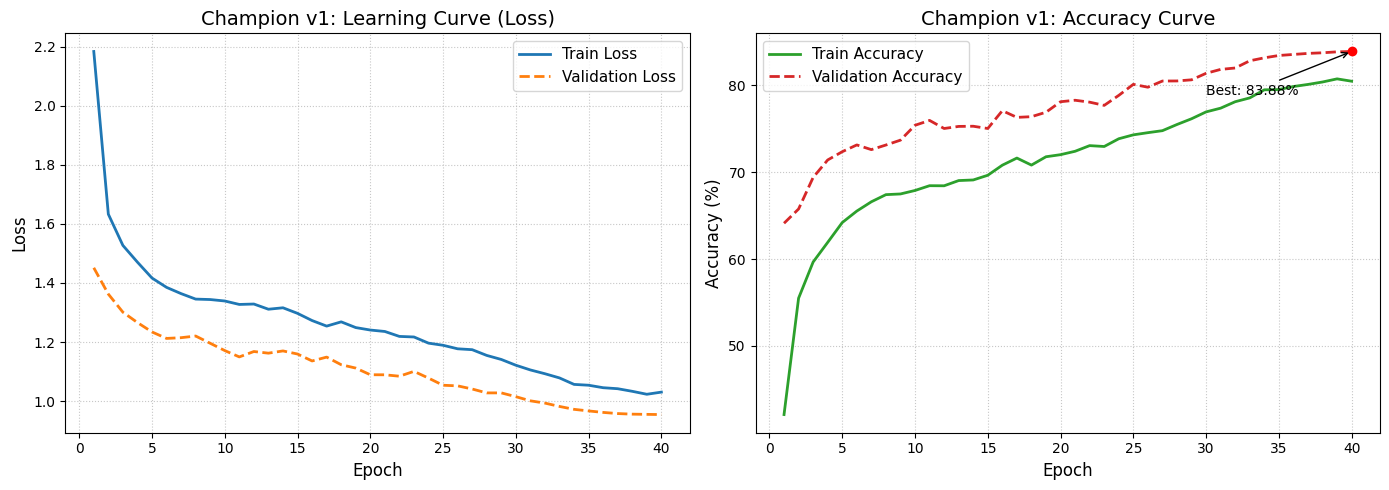

In [78]:
import matplotlib.pyplot as plt

# Extracted metrics for the 83.88% Champion run
epochs = list(range(1, 41))

train_loss = [2.1834, 1.6328, 1.5271, 1.4704, 1.4167, 1.3851, 1.3639, 1.3454, 1.3439, 1.3390, 
              1.3273, 1.3287, 1.3111, 1.3160, 1.2971, 1.2728, 1.2540, 1.2684, 1.2490, 1.2407, 
              1.2358, 1.2191, 1.2172, 1.1963, 1.1891, 1.1772, 1.1742, 1.1548, 1.1411, 1.1216, 
              1.1056, 1.0928, 1.0786, 1.0567, 1.0539, 1.0455, 1.0421, 1.0333, 1.0233, 1.0306]

val_loss = [1.4514, 1.3623, 1.3011, 1.2660, 1.2342, 1.2123, 1.2148, 1.2204, 1.1959, 1.1712, 
            1.1497, 1.1680, 1.1624, 1.1700, 1.1595, 1.1360, 1.1491, 1.1233, 1.1119, 1.0894, 
            1.0892, 1.0844, 1.1008, 1.0780, 1.0538, 1.0518, 1.0411, 1.0279, 1.0280, 1.0152, 
            1.0011, 0.9934, 0.9821, 0.9723, 0.9669, 0.9619, 0.9580, 0.9560, 0.9553, 0.9546]

train_acc = [42.11, 55.50, 59.66, 61.92, 64.20, 65.52, 66.59, 67.41, 67.49, 67.89, 
             68.44, 68.43, 69.03, 69.10, 69.64, 70.80, 71.62, 70.81, 71.77, 72.01, 
             72.40, 73.05, 72.95, 73.84, 74.29, 74.54, 74.77, 75.48, 76.14, 76.93, 
             77.36, 78.10, 78.54, 79.47, 79.50, 79.85, 80.09, 80.37, 80.73, 80.46]

val_acc = [64.12, 65.76, 69.39, 71.40, 72.35, 73.13, 72.59, 73.12, 73.68, 75.39, 
           75.95, 75.02, 75.26, 75.28, 75.02, 77.07, 76.30, 76.38, 76.89, 78.10, 
           78.27, 78.05, 77.68, 78.83, 80.10, 79.77, 80.48, 80.49, 80.62, 81.37, 
           81.82, 81.98, 82.81, 83.15, 83.42, 83.54, 83.66, 83.73, 83.84, 83.88]

# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Curve
ax1.plot(epochs, train_loss, label='Train Loss', color='tab:blue', linewidth=2)
ax1.plot(epochs, val_loss, label='Validation Loss', color='tab:orange', linewidth=2, linestyle='--')
ax1.set_title('Champion v1: Learning Curve (Loss)', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.7)

# Plot 2: Accuracy Curve
ax2.plot(epochs, train_acc, label='Train Accuracy', color='tab:green', linewidth=2)
ax2.plot(epochs, val_acc, label='Validation Accuracy', color='tab:red', linewidth=2, linestyle='--')
ax2.set_title('Champion v1: Accuracy Curve', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.7)

# Highlight the best epoch (Epoch 40)
best_epoch = 40
best_acc = 83.88
ax2.scatter(best_epoch, best_acc, color='red', zorder=5)
ax2.annotate(f'Best: {best_acc}%', 
             xy=(best_epoch, best_acc), 
             xytext=(best_epoch - 10, best_acc - 5),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10)

# Adjust layout and save the image
plt.tight_layout()
plt.savefig('champion_v13.pdf', dpi=300, bbox_inches='tight')
print("Plot successfully saved as 'champion_v13.png'.")

# Display the plot
plt.show()

Plot successfully saved as 'champion_v12.pdf'.


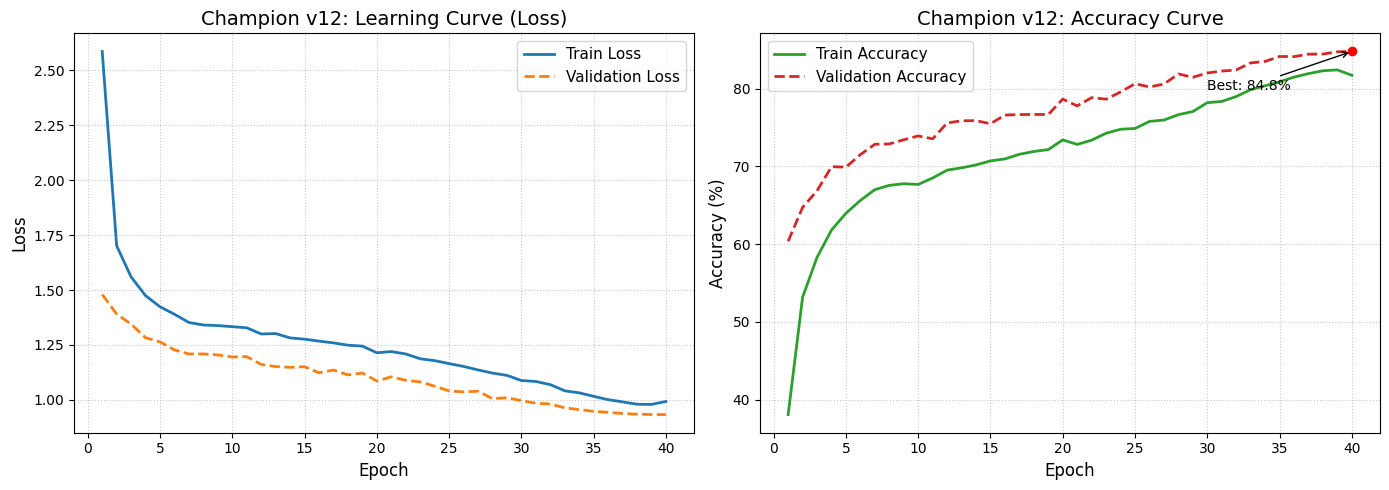

In [79]:
import matplotlib.pyplot as plt

# Extracted metrics for the Champion v12 run
epochs = list(range(1, 41))

train_loss = [2.5851, 1.7010, 1.5593, 1.4743, 1.4237, 1.3895, 1.3522, 1.3408, 1.3381, 1.3331, 
              1.3281, 1.2999, 1.3017, 1.2821, 1.2763, 1.2674, 1.2595, 1.2490, 1.2447, 1.2144, 
              1.2199, 1.2090, 1.1871, 1.1788, 1.1651, 1.1523, 1.1364, 1.1220, 1.1117, 1.0882, 
              1.0838, 1.0696, 1.0414, 1.0322, 1.0163, 1.0011, 0.9911, 0.9804, 0.9795, 0.9928]

val_loss = [1.4798, 1.3903, 1.3448, 1.2829, 1.2638, 1.2273, 1.2089, 1.2091, 1.2046, 1.1950, 
            1.1971, 1.1613, 1.1516, 1.1482, 1.1509, 1.1235, 1.1358, 1.1138, 1.1223, 1.0858, 
            1.1051, 1.0891, 1.0819, 1.0625, 1.0408, 1.0362, 1.0398, 1.0058, 1.0097, 0.9966, 
            0.9851, 0.9812, 0.9640, 0.9558, 0.9480, 0.9435, 0.9382, 0.9350, 0.9335, 0.9333]

train_acc = [38.07, 53.18, 58.31, 61.82, 63.98, 65.64, 67.02, 67.57, 67.78, 67.69, 
             68.52, 69.53, 69.83, 70.20, 70.72, 70.97, 71.57, 71.93, 72.18, 73.42, 
             72.84, 73.39, 74.28, 74.79, 74.89, 75.80, 75.98, 76.67, 77.07, 78.21, 
             78.37, 79.00, 79.89, 80.39, 80.89, 81.50, 81.95, 82.32, 82.43, 81.74]

val_acc = [60.38, 64.74, 66.88, 69.97, 69.92, 71.53, 72.86, 72.90, 73.44, 73.93, 
           73.56, 75.60, 75.88, 75.90, 75.50, 76.62, 76.68, 76.70, 76.69, 78.67, 
           77.80, 78.86, 78.66, 79.59, 80.65, 80.24, 80.60, 81.91, 81.48, 82.03, 
           82.28, 82.42, 83.33, 83.52, 84.16, 84.14, 84.46, 84.47, 84.76, 84.80]

# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Curve
ax1.plot(epochs, train_loss, label='Train Loss', color='tab:blue', linewidth=2)
ax1.plot(epochs, val_loss, label='Validation Loss', color='tab:orange', linewidth=2, linestyle='--')
ax1.set_title('Champion v12: Learning Curve (Loss)', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.7)

# Plot 2: Accuracy Curve
ax2.plot(epochs, train_acc, label='Train Accuracy', color='tab:green', linewidth=2)
ax2.plot(epochs, val_acc, label='Validation Accuracy', color='tab:red', linewidth=2, linestyle='--')
ax2.set_title('Champion v12: Accuracy Curve', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.7)

# Highlight the best epoch (Epoch 40)
best_epoch = 40
best_acc = 84.80
ax2.scatter(best_epoch, best_acc, color='red', zorder=5)
ax2.annotate(f'Best: {best_acc}%', 
             xy=(best_epoch, best_acc), 
             xytext=(best_epoch - 10, best_acc - 5),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10)

# Adjust layout and save the image
plt.tight_layout()
plt.savefig('champion_v12.pdf', dpi=300, bbox_inches='tight')
print("Plot successfully saved as 'champion_v12.pdf'.")

# Display the plot
plt.show()

Plot successfully saved as 'pancake.pdf'.


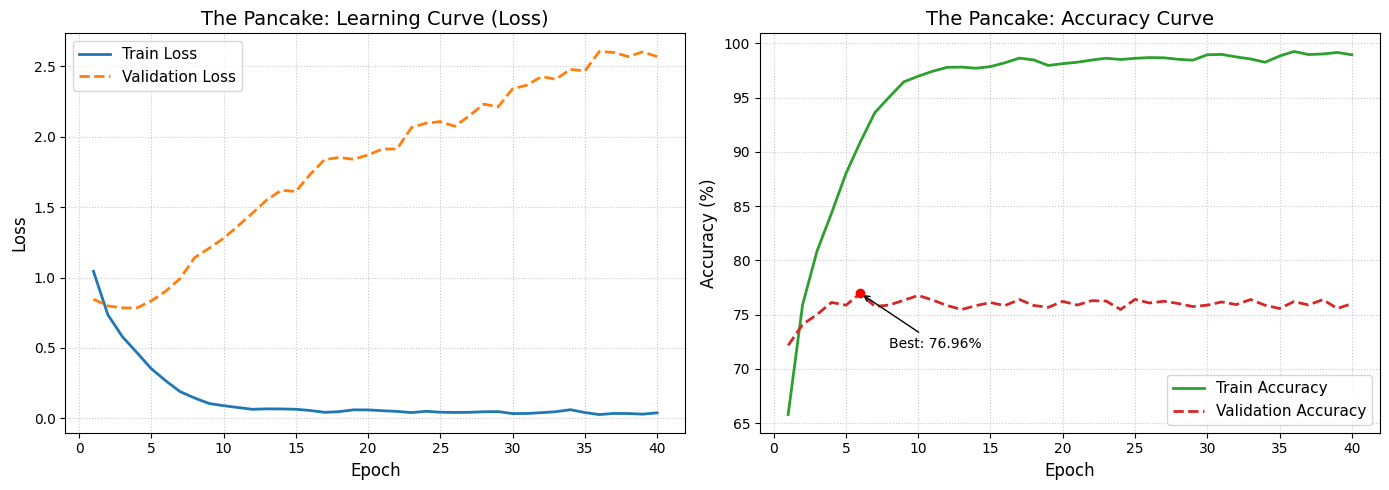

In [80]:
import matplotlib.pyplot as plt

# Extracted metrics for the Pancake model run
epochs = list(range(1, 41))

train_loss = [1.0441, 0.7348, 0.5802, 0.4675, 0.3526, 0.2665, 0.1893, 0.1441, 0.1053, 0.0895, 
              0.0766, 0.0640, 0.0672, 0.0664, 0.0641, 0.0554, 0.0423, 0.0475, 0.0601, 0.0596, 
              0.0539, 0.0489, 0.0406, 0.0497, 0.0432, 0.0415, 0.0426, 0.0463, 0.0477, 0.0336, 
              0.0342, 0.0401, 0.0470, 0.0611, 0.0409, 0.0265, 0.0344, 0.0340, 0.0294, 0.0389]

val_loss = [0.8456, 0.7984, 0.7846, 0.7837, 0.8340, 0.9029, 0.9935, 1.1415, 1.2077, 1.2787, 
            1.3666, 1.4573, 1.5521, 1.6203, 1.6112, 1.7335, 1.8386, 1.8530, 1.8402, 1.8709, 
            1.9134, 1.9130, 2.0648, 2.0967, 2.1079, 2.0744, 2.1488, 2.2321, 2.2127, 2.3410, 
            2.3672, 2.4273, 2.4094, 2.4794, 2.4675, 2.6060, 2.5991, 2.5696, 2.6031, 2.5695]

train_acc = [65.79, 75.91, 80.86, 84.34, 88.00, 90.92, 93.61, 95.05, 96.44, 96.96, 
             97.42, 97.78, 97.80, 97.70, 97.85, 98.20, 98.63, 98.46, 97.95, 98.12, 
             98.25, 98.45, 98.62, 98.50, 98.61, 98.68, 98.66, 98.52, 98.44, 98.94, 
             98.97, 98.74, 98.55, 98.25, 98.82, 99.24, 98.96, 99.01, 99.15, 98.94]

val_acc = [72.16, 74.09, 75.01, 76.12, 75.87, 76.96, 75.75, 75.88, 76.32, 76.76, 
           76.34, 75.83, 75.47, 75.83, 76.11, 75.83, 76.39, 75.84, 75.67, 76.22, 
           75.88, 76.28, 76.25, 75.47, 76.40, 76.07, 76.23, 76.02, 75.74, 75.87, 
           76.17, 75.92, 76.39, 75.86, 75.56, 76.20, 75.89, 76.38, 75.56, 76.01]

# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Curve
ax1.plot(epochs, train_loss, label='Train Loss', color='tab:blue', linewidth=2)
ax1.plot(epochs, val_loss, label='Validation Loss', color='tab:orange', linewidth=2, linestyle='--')
ax1.set_title('The Pancake: Learning Curve (Loss)', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.7)

# Plot 2: Accuracy Curve
ax2.plot(epochs, train_acc, label='Train Accuracy', color='tab:green', linewidth=2)
ax2.plot(epochs, val_acc, label='Validation Accuracy', color='tab:red', linewidth=2, linestyle='--')
ax2.set_title('The Pancake: Accuracy Curve', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.7)

# Highlight the best epoch (Epoch 6)
best_epoch = 6
best_acc = 76.96
ax2.scatter(best_epoch, best_acc, color='red', zorder=5)
ax2.annotate(f'Best: {best_acc}%', 
             xy=(best_epoch, best_acc), 
             xytext=(best_epoch + 2, best_acc - 5),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10)

# Adjust layout and save the image
plt.tight_layout()
plt.savefig('pancake.pdf', dpi=300, bbox_inches='tight')
print("Plot successfully saved as 'pancake.pdf'.")

# Display the plot
plt.show()

Plot successfully saved as 'tower.png'.


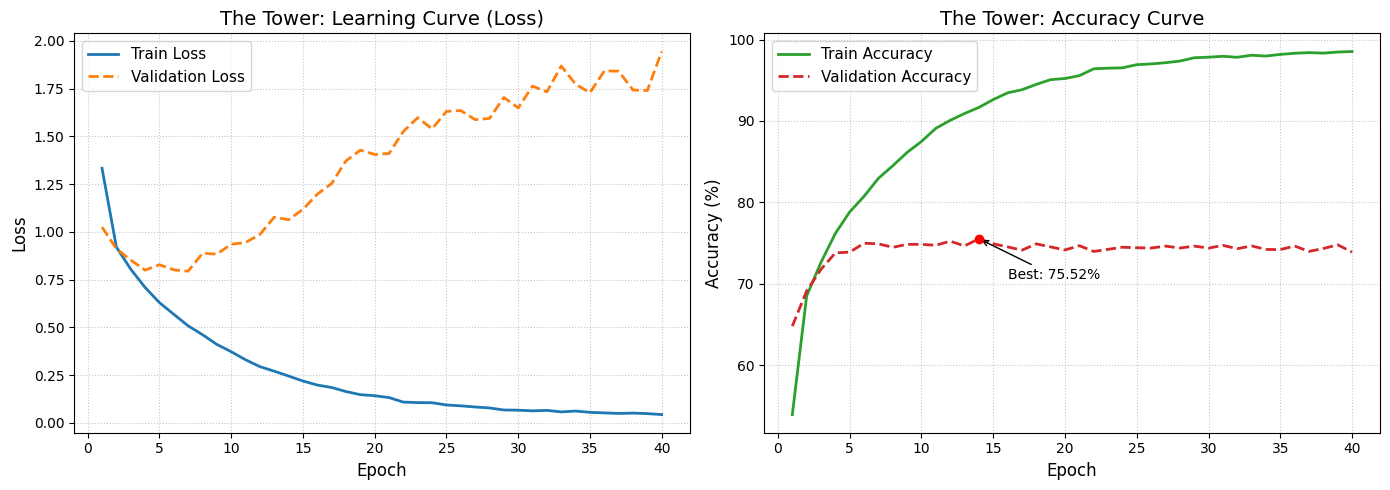

In [82]:
import matplotlib.pyplot as plt

# Extracted metrics for the Tower model run
epochs = list(range(1, 41))

train_loss = [1.3332, 0.9212, 0.8053, 0.7096, 0.6302, 0.5690, 0.5086, 0.4624, 0.4113, 0.3732, 
              0.3311, 0.2951, 0.2712, 0.2458, 0.2198, 0.1986, 0.1859, 0.1646, 0.1484, 0.1427, 
              0.1330, 0.1093, 0.1068, 0.1061, 0.0943, 0.0898, 0.0837, 0.0788, 0.0680, 0.0671, 
              0.0635, 0.0661, 0.0581, 0.0625, 0.0559, 0.0528, 0.0500, 0.0518, 0.0491, 0.0441]

val_loss = [1.0255, 0.9122, 0.8530, 0.8000, 0.8283, 0.8018, 0.7946, 0.8883, 0.8841, 0.9354, 
            0.9448, 0.9870, 1.0773, 1.0642, 1.1179, 1.1976, 1.2535, 1.3723, 1.4280, 1.4055, 
            1.4107, 1.5263, 1.5982, 1.5397, 1.6309, 1.6354, 1.5880, 1.5943, 1.7039, 1.6492, 
            1.7635, 1.7334, 1.8686, 1.7734, 1.7286, 1.8430, 1.8414, 1.7429, 1.7403, 1.9446]

train_acc = [53.92, 68.51, 72.63, 76.18, 78.82, 80.74, 82.95, 84.49, 86.13, 87.48, 
             89.09, 90.07, 90.91, 91.66, 92.62, 93.45, 93.83, 94.49, 95.07, 95.21, 
             95.56, 96.40, 96.48, 96.52, 96.91, 97.00, 97.15, 97.35, 97.76, 97.83, 
             97.94, 97.82, 98.07, 97.97, 98.17, 98.31, 98.39, 98.33, 98.46, 98.53]

val_acc = [64.78, 69.11, 71.77, 73.79, 73.88, 74.97, 74.90, 74.47, 74.84, 74.83, 
           74.72, 75.22, 74.64, 75.52, 74.90, 74.52, 74.12, 74.89, 74.52, 74.14, 
           74.67, 73.96, 74.22, 74.48, 74.42, 74.38, 74.62, 74.38, 74.62, 74.37, 
           74.71, 74.30, 74.64, 74.21, 74.19, 74.63, 73.97, 74.32, 74.78, 73.88]

# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Curve
ax1.plot(epochs, train_loss, label='Train Loss', color='tab:blue', linewidth=2)
ax1.plot(epochs, val_loss, label='Validation Loss', color='tab:orange', linewidth=2, linestyle='--')
ax1.set_title('The Tower: Learning Curve (Loss)', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.7)

# Plot 2: Accuracy Curve
ax2.plot(epochs, train_acc, label='Train Accuracy', color='tab:green', linewidth=2)
ax2.plot(epochs, val_acc, label='Validation Accuracy', color='tab:red', linewidth=2, linestyle='--')
ax2.set_title('The Tower: Accuracy Curve', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.7)

# Highlight the best epoch (Epoch 14)
best_epoch = 14
best_acc = 75.52
ax2.scatter(best_epoch, best_acc, color='red', zorder=5)
ax2.annotate(f'Best: {best_acc}%', 
             xy=(best_epoch, best_acc), 
             xytext=(best_epoch + 2, best_acc - 5),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10)

# Adjust layout and save the image
plt.tight_layout()
plt.savefig('tower.pdf', dpi=300, bbox_inches='tight')
print("Plot successfully saved as 'tower.png'.")

# Display the plot
plt.show()